In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import pymysql
from db_config import DB_HOST, DB_USER, DB_PASSWD, DB_NAME

try:
    with pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASSWD,
        database=DB_NAME
        # Notice I deleted the DictCursor line here!
    ) as connection:
        query = "SELECT id, ts, temp_dht, humidity, pm1, pm25, pm10 FROM project_kidbright_indoor where id <= 6737"
        df = pd.read_sql(query, connection)
        
        # Save it to CSV so we never deal with the DB again tonight
        # df.to_csv("aqi_data.csv", index=False)
        print("Data saved to CSV. Connection closed automatically.")
except Exception as e:
    print(f"Error: {e}")

df.head()

Data saved to CSV. Connection closed automatically.


/var/folders/x9/j5dq5m9n5_ddggn66zklqbv80000gn/T/ipykernel_8512/3462497748.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,ts,temp_dht,humidity,pm1,pm25,pm10
0,1,2026-03-27 19:32:55,33,5,22,33,38
1,2,2026-03-27 19:33:05,33,5,23,33,40
2,3,2026-03-27 19:33:16,33,5,23,33,41
3,4,2026-03-27 19:33:26,33,5,24,36,43
4,5,2026-03-27 19:33:36,33,5,24,35,44


In [7]:
df.shape

(6737, 7)

In [8]:
# information about the dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6737 entries, 0 to 6736
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        6737 non-null   int64         
 1   ts        6737 non-null   datetime64[us]
 2   temp_dht  6737 non-null   int64         
 3   humidity  6737 non-null   int64         
 4   pm1       6737 non-null   int64         
 5   pm25      6737 non-null   int64         
 6   pm10      6737 non-null   int64         
dtypes: datetime64[us](1), int64(6)
memory usage: 368.6 KB
None


In [9]:
df.nunique()

id          6737
ts          6737
temp_dht      12
humidity       3
pm1           37
pm25          45
pm10          55
dtype: int64

In [10]:
df.describe()

,id,ts,temp_dht,humidity,pm1,pm25,pm10
count,6737.000000,6737,6737.000000,6737.000000,6737.000000,6737.000000,6737.000000
mean,3369.000000,2026-03-30 09:02:41.771560,30.360101,4.980110,5.673890,9.343328,10.754490
min,1.000000,2026-03-27 19:32:55,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1685.000000,2026-03-29 02:53:01,30.000000,5.000000,3.000000,4.000000,6.000000
50%,3369.000000,2026-03-30 08:57:41,31.000000,5.000000,6.000000,9.000000,10.000000
75%,5053.000000,2026-03-31 15:02:22,32.000000,5.000000,7.000000,13.000000,15.000000
max,6737.000000,2026-04-01 21:07:03,35.000000,6.000000,49.000000,61.000000,76.000000
std,1944.948714,NaN,2.767688,0.316165,5.408115,7.719731,8.745205


In [11]:
#group data
df = df.drop(columns=['id'])

# 2. Convert 'ts' to datetime objects
df['ts'] = pd.to_datetime(df['ts'])

# 3. Set 'ts' as index and resample to 10-minute intervals, calculating the mean
df = df.set_index('ts').resample('10min').mean()

# Reset index so 'ts' becomes a column again
df = df.reset_index()

print(df)

                     ts   temp_dht  humidity        pm1       pm25       pm10
0   2026-03-27 19:30:00  33.000000       5.0  18.928571  27.571429  33.642857
1   2026-03-27 19:40:00        NaN       NaN        NaN        NaN        NaN
2   2026-03-27 19:50:00        NaN       NaN        NaN        NaN        NaN
3   2026-03-27 20:00:00        NaN       NaN        NaN        NaN        NaN
4   2026-03-27 20:10:00        NaN       NaN        NaN        NaN        NaN
..                  ...        ...       ...        ...        ...        ...
725 2026-04-01 20:20:00  28.888889       5.0   4.333333   7.111111   9.555556
726 2026-04-01 20:30:00  28.000000       5.0   4.444444   8.666667  11.000000
727 2026-04-01 20:40:00  28.000000       5.0   4.800000   8.200000   9.900000
728 2026-04-01 20:50:00  28.000000       5.0  12.333333  15.555556  17.000000
729 2026-04-01 21:00:00  28.000000       5.0   3.857143   7.857143   8.571429

[730 rows x 6 columns]


In [12]:
null_counts = df.isnull().sum()
zero_counts = (df == 0).sum()
blank_counts = (df == '').sum()
bad_pm_count = ((df['pm1'] < 5) & (df['pm25'] < 5) & (df['pm10'] < 5)).sum()
impossible_pm_logic = (df['pm25'] > df['pm10']).sum()
print(f"{null_counts}\n\n{zero_counts}\n\n{blank_counts}\n\n{bad_pm_count}\n\n{impossible_pm_logic}")

ts           0
temp_dht    21
humidity    21
pm1         21
pm25        21
pm10        21
dtype: int64

ts           0
temp_dht     0
humidity     0
pm1         80
pm25        76
pm10        76
dtype: int64

ts          0
temp_dht    0
humidity    0
pm1         0
pm25        0
pm10        0
dtype: int64

147

0


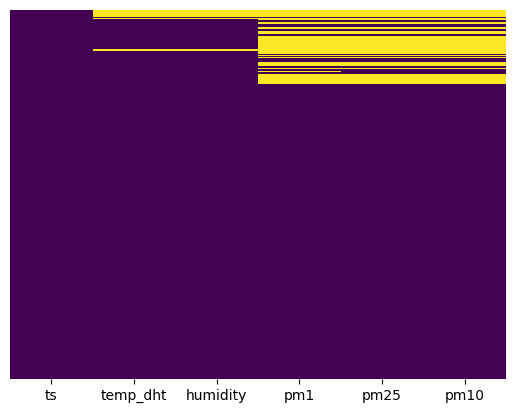

In [13]:
sns.heatmap(df.isnull()|(df == 0) | (df == ''), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

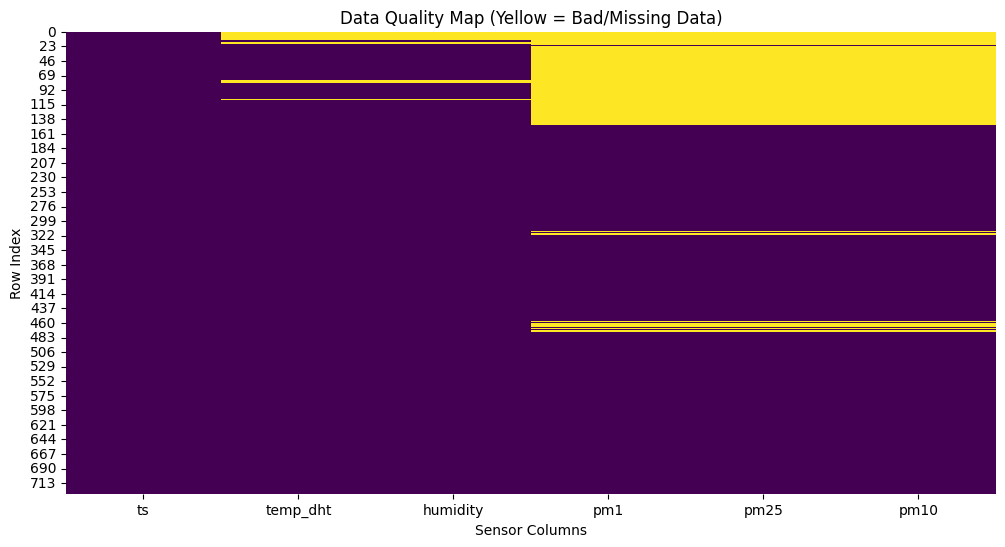

In [14]:
is_bad = df.isnull() | (df == 0) | (df == '')

# 2. Add your specific logic for PM values < 5
# This identifies rows where all PM sensors are below 5
pm_low_mask = (df['pm1'] < 5) & (df['pm25'] < 5) & (df['pm10'] < 5)

# We mark these specific rows as 'bad' in the PM columns
for col in ['pm1', 'pm25', 'pm10']:
    is_bad[col] = is_bad[col] | pm_low_mask

# 3. Plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(is_bad, cbar=False, cmap='viridis')

plt.title('Data Quality Map (Yellow = Bad/Missing Data)')
plt.xlabel('Sensor Columns')
plt.ylabel('Row Index')
plt.show()

In [15]:
df = df.replace(0, np.nan)
df = df.replace("", np.nan)
pm_bad_mask = (df['pm1'] < 5) & (df['pm25'] < 5) & (df['pm10'] < 5)
df.loc[pm_bad_mask, ['pm1', 'pm25', 'pm10']] = np.nan

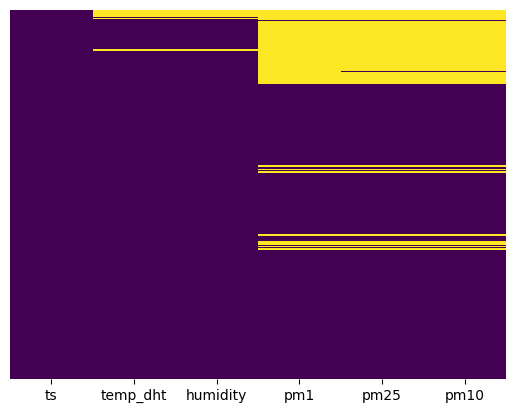

In [16]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [17]:
df = df.dropna()
df.head()

,ts,temp_dht,humidity,pm1,pm25,pm10
0,2026-03-27 19:30:00,33.000000,5.0,18.928571,27.571429,33.642857
21,2026-03-27 23:00:00,28.000000,5.0,6.500000,7.000000,7.300000
111,2026-03-28 14:00:00,29.700000,4.5,5.100000,6.100000,6.400000
148,2026-03-28 20:10:00,31.600000,5.0,5.200000,8.600000,10.500000
149,2026-03-28 20:20:00,30.666667,5.0,10.000000,15.111111,17.444444


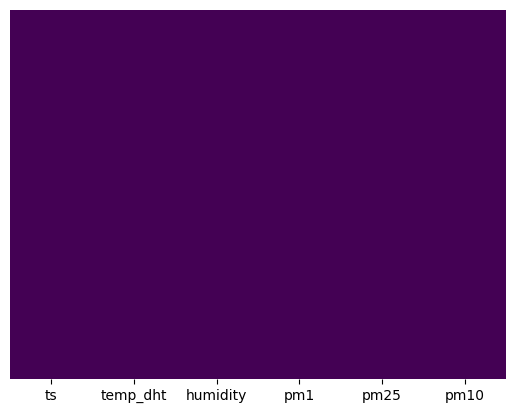

In [18]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

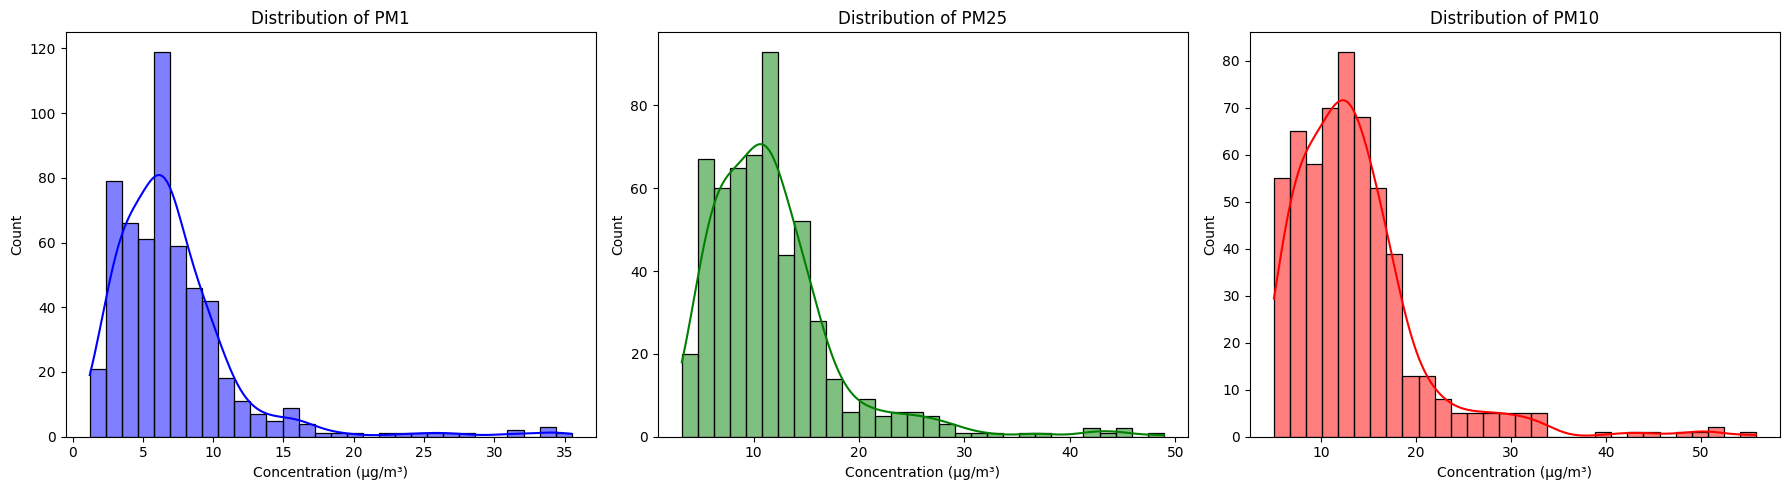

In [19]:
# Create a figure for the 3 histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pm_list = ['pm1', 'pm25', 'pm10']
colors = ['blue', 'green', 'red']

for i, col in enumerate(pm_list):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Distribution of {col.upper()}')
    axes[i].set_xlabel('Concentration (µg/m³)')

plt.tight_layout()
plt.show()

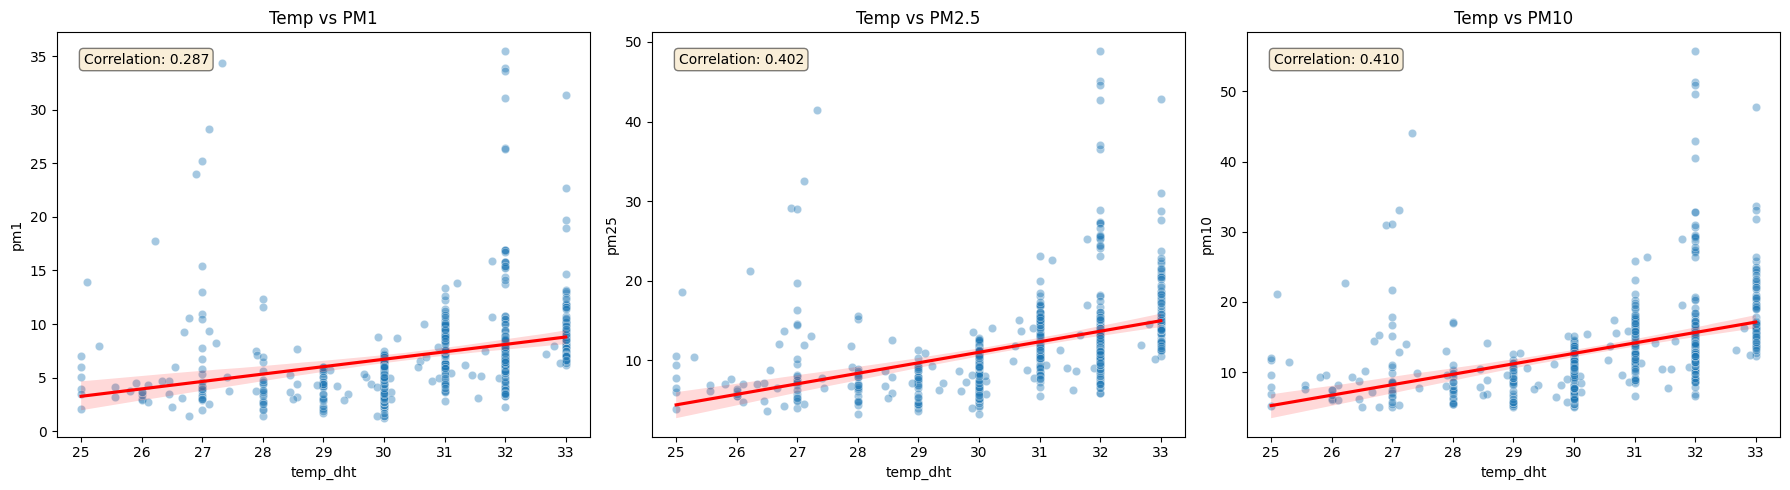

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='temp_dht', y='pm1', ax=axes[0], alpha=0.4).set_title('Temp vs PM1')
sns.scatterplot(data=df, x='temp_dht', y='pm25', ax=axes[1], alpha=0.4).set_title('Temp vs PM2.5')
sns.scatterplot(data=df, x='temp_dht', y='pm10', ax=axes[2], alpha=0.4).set_title('Temp vs PM10')

pm_sensors = ['pm1', 'pm25', 'pm10']
for i, (ax, pm_col) in enumerate(zip(axes.flat, pm_sensors)):
    sns.regplot(data=df, x='temp_dht', y=pm_col, ax=ax, scatter=False, color='red')
    
    corr = df['temp_dht'].corr(df[pm_col])
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

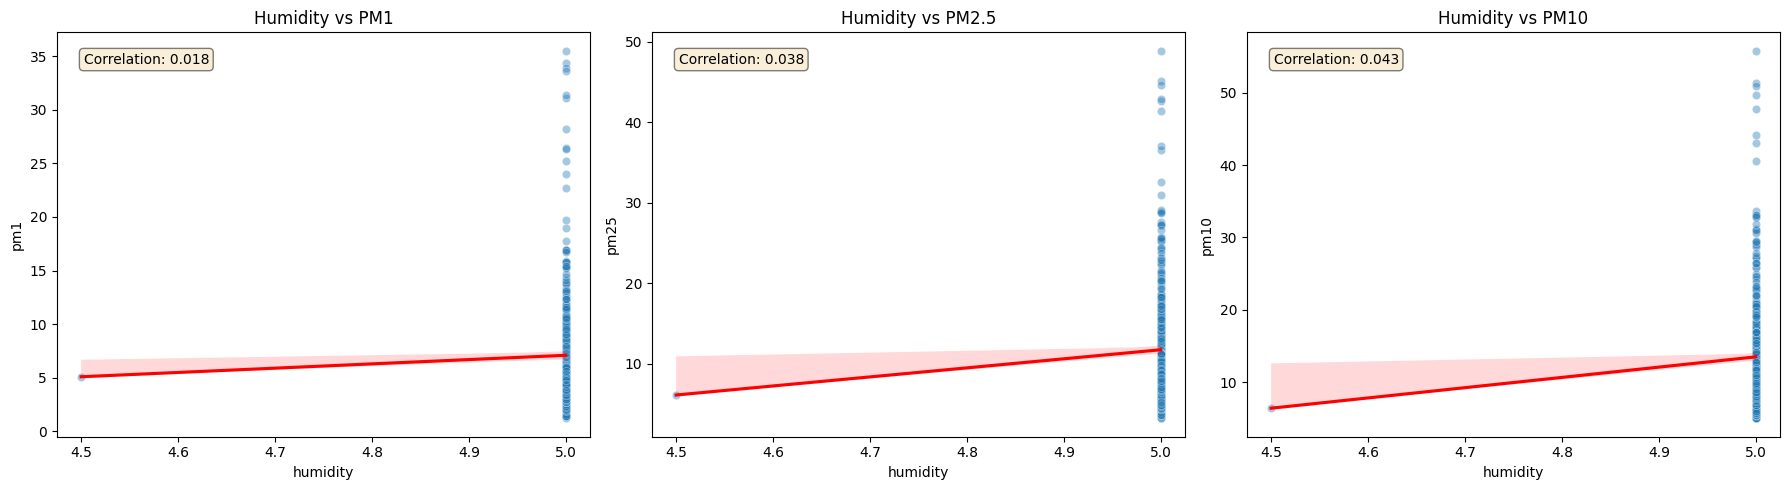

In [22]:
# Humidity vs PM Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='humidity', y='pm1', ax=axes[0], alpha=0.4).set_title('Humidity vs PM1')
sns.scatterplot(data=df, x='humidity', y='pm25', ax=axes[1], alpha=0.4).set_title('Humidity vs PM2.5')
sns.scatterplot(data=df, x='humidity', y='pm10', ax=axes[2], alpha=0.4).set_title('Humidity vs PM10')

pm_sensors = ['pm1', 'pm25', 'pm10']
for i, (ax, pm_col) in enumerate(zip(axes.flat, pm_sensors)):
    sns.regplot(data=df, x='humidity', y=pm_col, ax=ax, scatter=False, color='red')
    
    corr = df['humidity'].corr(df[pm_col])
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

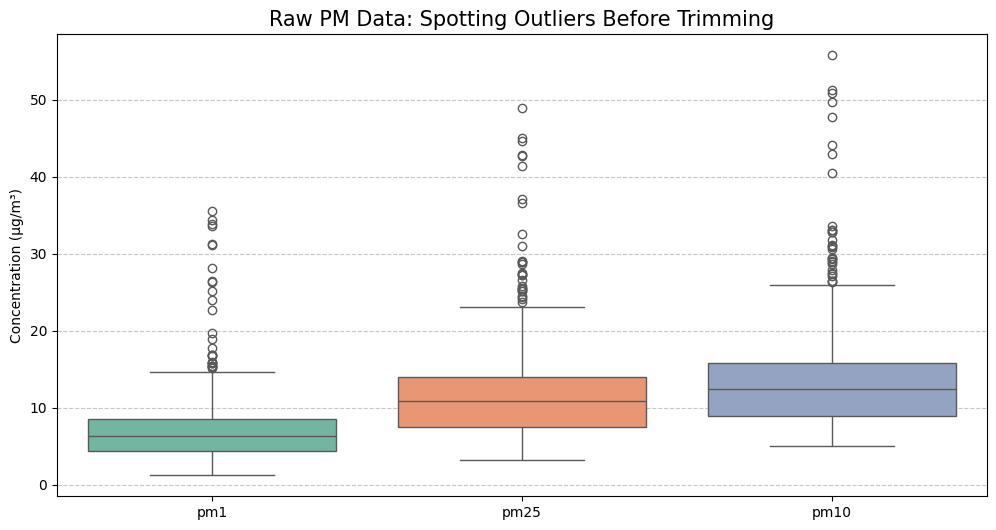

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns we're looking at
pm_cols = ['pm1', 'pm25', 'pm10']

# Create the figure
plt.figure(figsize=(12, 6))

# Use seaborn to create the boxplots
sns.boxplot(data=df[pm_cols], palette="Set2")

plt.title('Raw PM Data: Spotting Outliers Before Trimming', fontsize=15)
plt.ylabel('Concentration (µg/m³)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

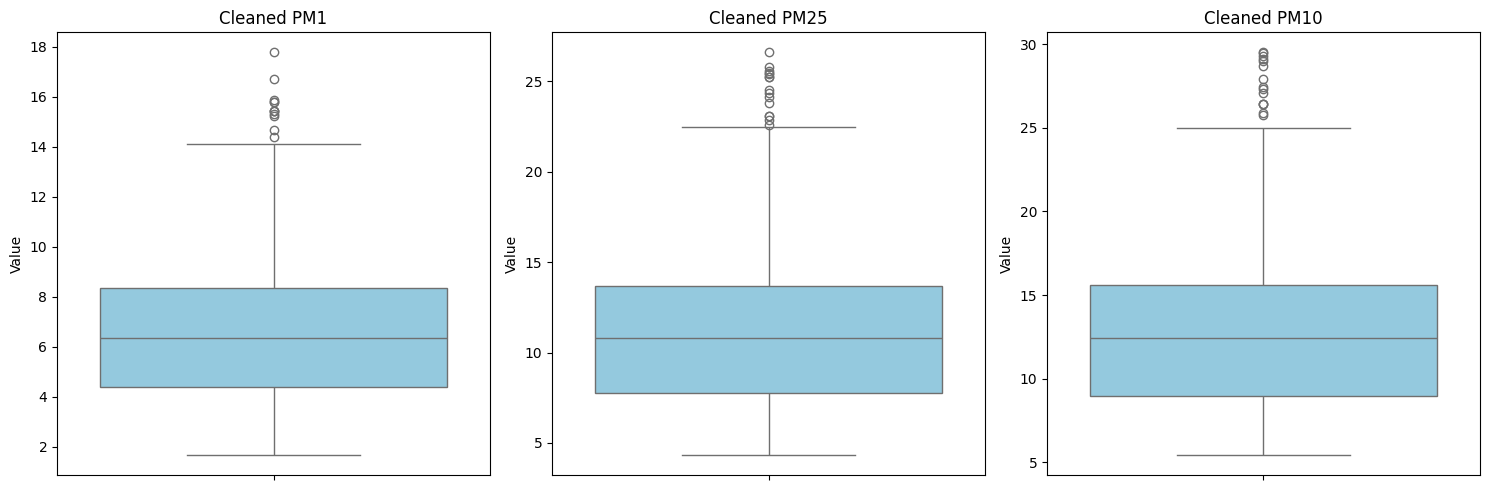

Outliers removed. Remaining data points: 529


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pm_cols = ['pm1', 'pm25', 'pm10']

for col in pm_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(pm_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Cleaned {col.upper()}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

print(f"Outliers removed. Remaining data points: {len(df)}")

In [94]:
df.to_csv("indoor.csv",index=False)